In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/processed/kc_house_clean.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
print(df.shape)

df.info()

df.describe()

(20467, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20467 entries, 0 to 20466
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             20467 non-null  int64  
 1   date           20467 non-null  object 
 2   price          20467 non-null  float64
 3   bedrooms       20467 non-null  int64  
 4   bathrooms      20467 non-null  float64
 5   sqft_living    20467 non-null  int64  
 6   sqft_lot       20467 non-null  int64  
 7   floors         20467 non-null  float64
 8   waterfront     20467 non-null  int64  
 9   view           20467 non-null  int64  
 10  condition      20467 non-null  int64  
 11  grade          20467 non-null  int64  
 12  sqft_above     20467 non-null  int64  
 13  sqft_basement  20467 non-null  int64  
 14  yr_built       20467 non-null  int64  
 15  yr_renovated   20467 non-null  int64  
 16  zipcode        20467 non-null  int64  
 17  lat            20467 non-null  float64

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.046700e+04,2.046700e+04,20467.000000,20467.000000,20467.000000,2.046700e+04,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000,20467.000000
mean,4.603223e+09,4.769846e+05,3.329750,2.051632,1975.558167,1.461041e+04,1.476035,0.002980,0.172668,3.406361,7.530561,1708.330972,267.227195,1970.811013,74.681145,98078.555773,47.556888,-122.213265,1922.255191,12447.084526
std,2.877364e+09,2.083713e+05,0.912885,0.711906,774.833460,4.010956e+04,0.537033,0.054513,0.640950,0.647228,1.039192,727.296461,409.031661,29.160540,378.761647,53.336953,0.141038,0.142412,614.932010,26538.592250
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.131701e+09,3.150000e+05,3.000000,1.500000,1400.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1170.000000,0.000000,1951.000000,0.000000,98033.000000,47.460400,-122.330000,1470.000000,5046.000000
50%,3.905082e+09,4.375000e+05,3.000000,2.000000,1860.000000,7.500000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1520.000000,0.000000,1974.000000,0.000000,98065.000000,47.567000,-122.232000,1800.000000,7542.000000
75%,7.338101e+09,6.000000e+05,4.000000,2.500000,2431.000000,1.031900e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2100.000000,510.000000,1996.000000,0.000000,98118.000000,47.679800,-122.123000,2280.000000,9883.500000
max,9.900000e+09,1.127500e+06,33.000000,7.500000,7480.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,12.000000,5710.000000,2720.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5380.000000,871200.000000


In [4]:
df["house_age"] = 2015 - df["yr_built"]

In [5]:
CITY_LAT = 47.6062
CITY_LONG = -122.3321

In [6]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    dLat = radians(lat2-lat1)
    dLon = radians(lon2-lon1)

    a = sin(dLat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dLon/2)**2

    c = 2*atan2(sqrt(a),sqrt(1-a))

    return R*c

In [7]:
df["distance_city_center"] = df.apply(

    lambda row:

    haversine(

        row["lat"],
        row["long"],
        CITY_LAT,
        CITY_LONG

    ),

    axis=1

)

In [8]:
df[["house_age","distance_city_center"]].head()

,house_age,distance_city_center
0,60,11.972687
1,64,12.802819
2,82,16.416960
3,50,10.538233
4,28,21.553979


In [9]:
df.to_csv("../data/processed/kc_house_featured.csv",index=False)

In [10]:
y = df["price"]

In [11]:
X = df.drop(

    ["price","id","date"],

    axis=1

)

In [12]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [13]:
model = XGBRegressor(

    random_state=42

)

model.fit(

    X_train,

    y_train

)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [14]:
prediction = model.predict(X_test)

In [15]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        prediction

    )

)

In [16]:
mape = mean_absolute_percentage_error(

    y_test,

    prediction

)

In [17]:
print("RMSE :",rmse)

print("MAPE :",mape)

RMSE : 74709.8211066891
MAPE : 0.11925517375147202


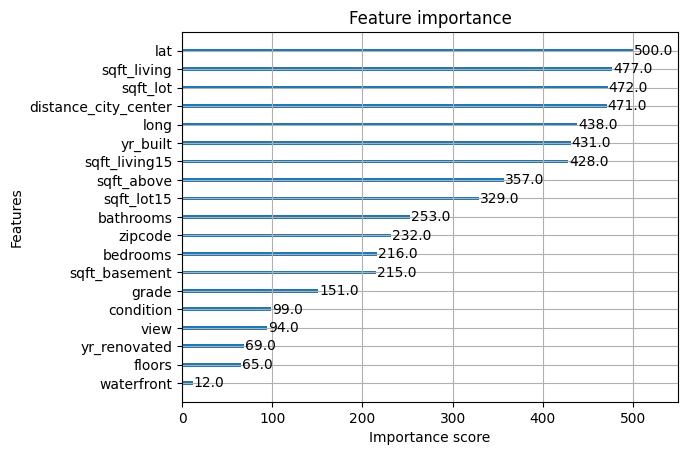

In [18]:
from xgboost import plot_importance

plot_importance(model)

plt.show()

In [21]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/xgboost_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Week 2 Summary

## Completed Tasks
- Loaded cleaned dataset
- Performed feature engineering
- Created House Age feature
- Calculated Distance to City Center
- Selected features and target
- Split dataset into train and test sets
- Trained XGBoost baseline model
- Evaluated using RMSE and MAPE
- Saved trained model
- Saved predictions and metrics

## Results
- RMSE: 74709.82
- MAPE: 11.93%

## Baseline Model Limitations
- Uses only tabular features.
- Ignores neighbouring house influence.
- Does not capture spatial relationships.
- Performance may decrease in rapidly changing neighbourhoods.
- Week 3 will address these limitations using graph-based modeling.